# Exploratory Data Analysis of Retail Sales

## Problem Statement
The objective of this project is to analyze a real-world retail sales dataset using Python libraries such as Pandas, NumPy, and Matplotlib. Through this analysis, we aim to uncover sales trends, identify high-performing product categories, and gain insights that can support better business decision-making.

## Tools & Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Google Colab


Importing Librarires

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


**Load & Understand the Dataset**

Load the Dataset

In [ ]:
df = pd.read_csv("retail_sales_dataset.csv")


In [ ]:
df.head()


,Order_ID,Order_Date,Region,Category,Sub_Category,Sales,Quantity,Profit
0,ORD100000,2019-01-01 00:00:00.000000000,South America,Office Supplies,Binders,2645.04,12,289.12
1,ORD100001,2019-01-01 01:03:06.123722474,Africa,Office Supplies,Paper,3501.00,3,296.24
2,ORD100002,2019-01-01 02:06:12.247444948,North America,Office Supplies,Binders,3921.14,13,249.71
3,ORD100003,2019-01-01 03:09:18.371167423,Africa,Office Supplies,Phones,3221.82,4,327.22
4,ORD100004,2019-01-01 04:12:24.494889897,Africa,Technology,Accessories,5171.96,7,992.33


The first few rows of the dataset give an overview of how the data is structured, including order details, product categories, sales amounts, and profit values.


In [ ]:
df.shape


(50000, 8)

The dataset contains a large number of records, making it suitable for realistic exploratory data analysis and trend identification.


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order_ID      50000 non-null  object 
 1   Order_Date    50000 non-null  object 
 2   Region        50000 non-null  object 
 3   Category      50000 non-null  object 
 4   Sub_Category  50000 non-null  object 
 5   Sales         50000 non-null  float64
 6   Quantity      50000 non-null  int64  
 7   Profit        50000 non-null  float64
dtypes: float64(2), int64(1), object(5)
memory usage: 3.1+ MB


This step helps identify data types of each column and checks whether there are any missing values that need to be handled during data cleaning.


In [ ]:
df.describe()


,Sales,Quantity,Profit
count,50000.000000,50000.000000,50000.000000
mean,2630.952451,7.511400,307.888722
std,1742.967730,4.027768,384.183881
min,12.930000,1.000000,-279.840000
25%,1228.910000,4.000000,48.667500
50%,2442.720000,8.000000,169.350000
75%,3719.742500,11.000000,397.575000
max,9684.150000,14.000000,2110.450000


The statistical summary provides insights into numerical columns such as sales, quantity, and profit, including their distribution and variability.


**Data Cleaning & Preparation**

In [ ]:
df.isnull().sum()


,0
Order_ID,0
Order_Date,0
Region,0
Category,0
Sub_Category,0
Sales,0
Quantity,0
Profit,0


Checking for missing values helps ensure data quality.


In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])


Converting the order date to datetime format allows time-based analysis such as monthly and yearly sales trends.


**Create New Time-Based Columns**

In [ ]:
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Month_Name'] = df['Order_Date'].dt.month_name()


In [ ]:
df[['Order_Date', 'Year', 'Month', 'Month_Name']].head()


,Order_Date,Year,Month,Month_Name
0,2019-01-01 00:00:00.000000000,2019,1,January
1,2019-01-01 01:03:06.123722474,2019,1,January
2,2019-01-01 02:06:12.247444948,2019,1,January
3,2019-01-01 03:09:18.371167423,2019,1,January
4,2019-01-01 04:12:24.494889897,2019,1,January


To enable time-based analysis, the order date column was converted into separate year and month components.
This allows the identification of seasonal trends, monthly patterns, and long-term sales performance.


## Key Performance Indicators (KPIs)


In [ ]:
total_orders = df['Order_ID'].nunique()
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
avg_order_value = df['Sales'].mean()
profit_margin = (total_profit / total_sales) * 100

total_orders, total_sales, total_profit, avg_order_value, profit_margin


(50000,
 np.float64(131547622.54),
 np.float64(15394436.090000002),
 np.float64(2630.9524508),
 np.float64(11.702557440989843))

KPIs provide a quick overview of overall business performance and are commonly used by management for high-level decision-making.


# Overall Business Performance

In [ ]:
total_sales = df['Sales'].sum()
total_sales


np.float64(131547622.54)

Total sales represent the overall revenue generated from all orders in the dataset.
This metric gives a high-level understanding of the business scale.


In [ ]:
total_profit = df['Profit'].sum()
total_profit


np.float64(15394436.090000002)

Total profit indicates whether the business is overall profitable or operating at a loss during the given period.


In [ ]:
average_sales = df['Sales'].mean()
average_sales


np.float64(2630.9524508)

The average sales value shows how much revenue is generated per order on average.
This helps assess customer purchasing behavior.


**Sales & Profit by Category**

In [ ]:
category_sales = df.groupby('Category')['Sales'].sum()
category_sales


,Sales
Category,
Furniture,39370852.04
Office Supplies,32675859.55
Technology,59500910.95


Grouping sales by product category helps identify which categories contribute the most to overall revenue.


In [ ]:
category_profit = df.groupby('Category')['Profit'].sum()
category_profit


,Profit
Category,
Furniture,955870.34
Office Supplies,2726765.60
Technology,11711800.15


Analyzing profit by category reveals whether high sales categories are also profitable, which is critical for business decisions.


**Sales Performance by Region**

In [ ]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_sales


,Sales
Region,
Europe,26675060.12
South America,26590116.81
Africa,26489988.94
Asia,26170938.93
North America,25621517.74


This analysis shows which geographical regions generate the highest sales, helping businesses focus marketing and expansion efforts.


**Time-Based Overview**

In [ ]:
yearly_sales = df.groupby('Year')['Sales'].sum()
yearly_sales


,Sales
Year,
2019,21979100.29
2020,22055894.60
2021,21831164.04
2022,21842650.80
2023,21875655.32
2024,21963157.49


Year-wise sales analysis helps identify long-term growth patterns and overall business performance trends.


To compare sales contribution across product categories.

# Data Visualization using Matplotlib

**Category-wise Sales (Bar Chart)**

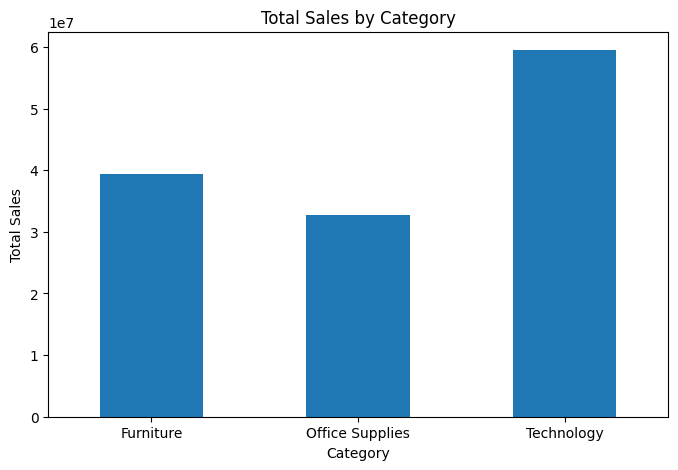

In [ ]:
plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()


This bar chart compares total sales across different product categories.
It helps identify which category contributes the most to overall revenue.


**Category-wise Profit (Bar Chart)**

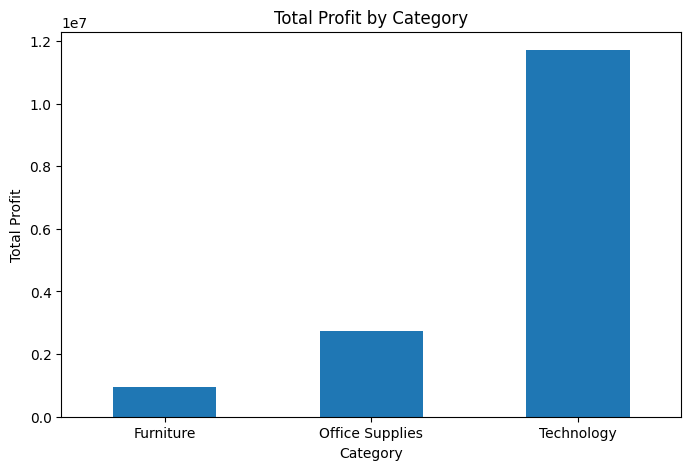

In [ ]:
plt.figure(figsize=(8,5))
category_profit.plot(kind='bar')
plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.show()


This visualization highlights profit distribution across categories, revealing whether top-selling categories are also the most profitable.


**Yearly Sales Trend (Line Chart)**

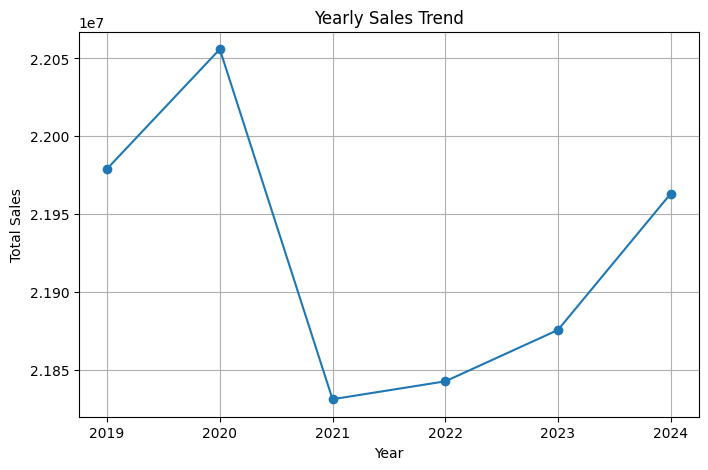

In [ ]:
plt.figure(figsize=(8,5))
yearly_sales.plot(kind='line', marker='o')
plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()


The line chart illustrates how sales have changed over the years, helping identify growth patterns and long-term business performance.


**Region-wise Sales Comparison**

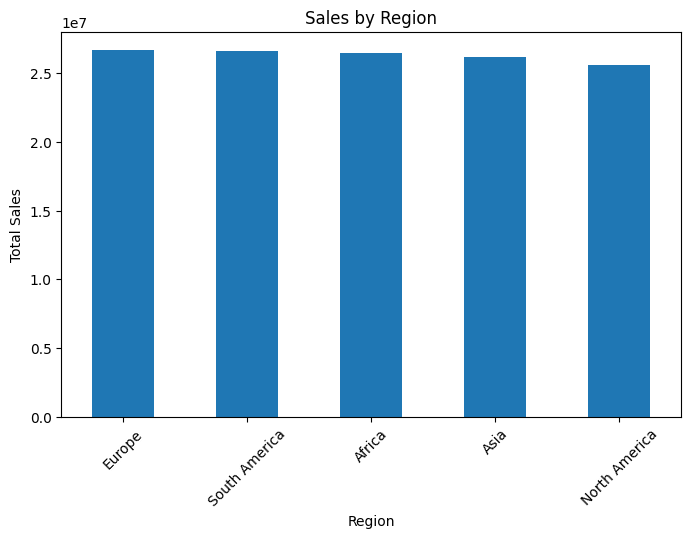

In [ ]:
plt.figure(figsize=(8,5))
region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


This chart compares sales across regions, helping businesses prioritize regions with higher revenue potential.


**Profit Margin by Category**

In [ ]:
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100
profit_margin_category = df.groupby('Category')['Profit_Margin'].mean()


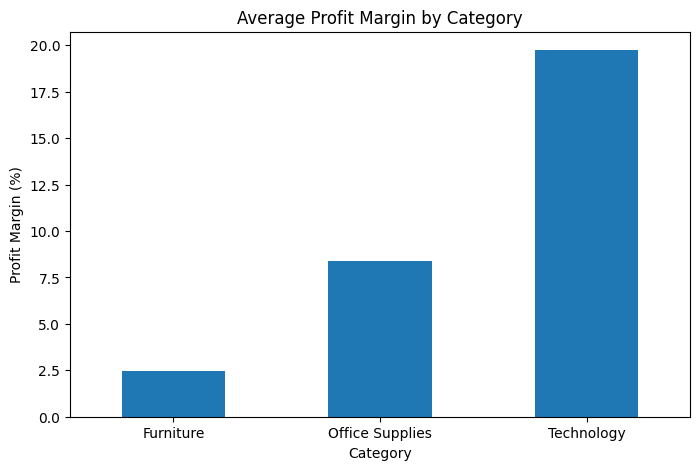

In [ ]:
plt.figure(figsize=(8,5))
profit_margin_category.plot(kind='bar')
plt.title("Average Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=0)
plt.show()


**Sales Distribution**

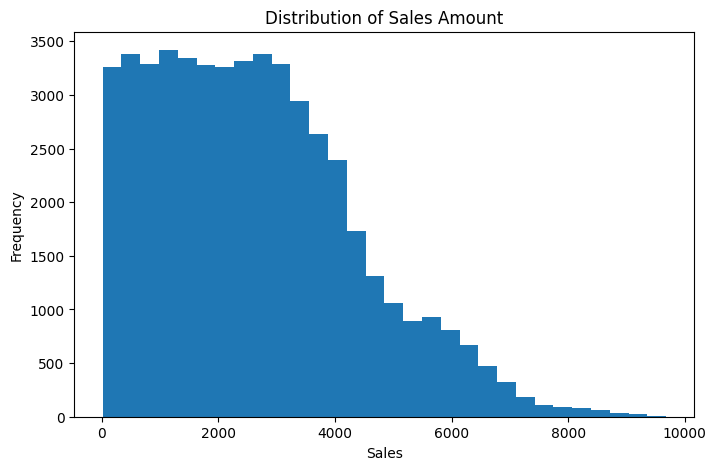

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['Sales'], bins=30)
plt.title("Distribution of Sales Amount")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()


This histogram shows how sales values are distributed, helping understand customer purchasing behavior and order size frequency.


**Monthly Trend (Seasonality Proof)**

In [ ]:
monthly_sales = df.groupby(['Year','Month'])['Sales'].sum().reset_index()


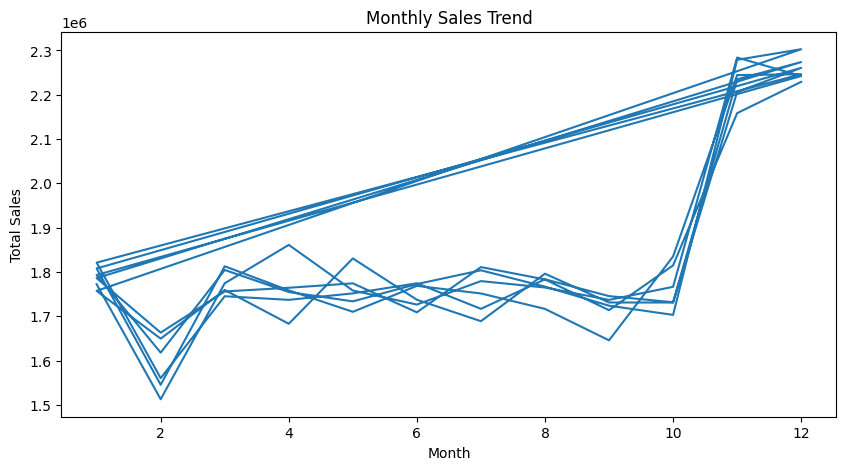

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales['Month'], monthly_sales['Sales'])
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()


Monthly sales trends highlight seasonal patterns, particularly increased sales during year-end months.


**Loss-Making Orders Section**

In [ ]:
loss_orders = df[df['Profit'] < 0]
loss_orders.groupby('Category')['Order_ID'].count()


,Order_ID
Category,
Furniture,5555


Identifying loss-making orders helps businesses investigate pricing, cost structure, and discount strategies.


## Key Insights


1. Technology products generate the highest sales and profit, indicating strong demand and higher profit margins compared to other categories.

2. Furniture sales contribute significantly to revenue but show inconsistent profitability, suggesting higher costs or pricing challenges.

3. Office Supplies have lower individual sales values but provide stable profit through frequent purchases.

4. Sales show a noticeable increase during November and December, highlighting strong seasonal demand and the importance of year-end marketing strategies.

5. Regional analysis indicates that certain regions consistently outperform others, suggesting opportunities for targeted expansion and investment.
